In [7]:
import torch
import numpy as np
import torch.nn as nn
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import torchvision
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [2]:
print(torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

True
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU


In [9]:
x = torch.ones(2, 2, dtype = torch.float16)
x

tensor([[1., 1.],
        [1., 1.]], dtype=torch.float16)

In [10]:
z = torch.randn(3, requires_grad = True)
alpha = z + z
beta = alpha * alpha
beta = beta.mean()
beta.backward()
z.grad

tensor([-2.9772,  2.8197, -2.4673])

In [11]:
# var.requires_grad_(False)
# var_2 = var.detach()
# with torch.no_grad():

In [12]:
weights = torch.ones(4, requires_grad = True)
for epoch in range(3):
    model = (weights * weights).mean()
    model.backward()
    print(weights.grad)
    weights.grad.zero_()

tensor([0.5000, 0.5000, 0.5000, 0.5000])
tensor([0.5000, 0.5000, 0.5000, 0.5000])
tensor([0.5000, 0.5000, 0.5000, 0.5000])


In [13]:
x = torch.tensor(3.0)
y = torch.tensor(6.0)
w = torch.tensor(1.0, requires_grad = True)
y_hat = w * x
loss = (y_hat - y) ** 2
print(loss)
loss.backward()
print(w.grad)

tensor(9., grad_fn=<PowBackward0>)
tensor(-18.)


In [14]:
x = np.array([2, 3, 4, 5], dtype = np.float32)
y = np.array([6, 9, 12, 15], dtype = np.float32)
w = 1.0

def forward(x):
    return w * x

def loss(y, y_hat):
    return ((y_hat - y) ** 2).mean()

def gradient(x, y, y_hat):
    return np.dot(2 * x, y_hat - y).mean()

print(f'Before training: f(5) = {forward(5):.3f}')

learning_rate = 0.01
epochs = 10

for epoch in range(epochs):
    y_hat = forward(x)
    l = loss(y, y_hat)
    grad = gradient(x, y, y_hat)
    w -= learning_rate * grad
    if epoch % 1 == 0:
        print('Loss:', l)
        print('Gradient:', grad)

print(f'After training: f(5) = {forward(5):.3f}')

Before training: f(5) = 5.000
Loss: 54.0
Gradient: -216.0
Loss: 0.34559935
Gradient: 17.279984
Loss: 0.0022118357
Gradient: -1.3823986
Loss: 1.4156235e-05
Gradient: 0.110593796
Loss: 9.080941e-08
Gradient: -0.008857727
Loss: 6.0163075e-10
Gradient: 0.0007209778
Loss: 2.9558578e-12
Gradient: -4.9591064e-05
Loss: 0.0
Gradient: 0.0
Loss: 0.0
Gradient: 0.0
Loss: 0.0
Gradient: 0.0
After training: f(5) = 15.000


In [15]:
x = torch.tensor([2, 3, 4, 5], dtype = torch.float32)
y = torch.tensor([6, 9, 12, 15], dtype = torch.float32)
w = torch.tensor(1.0, dtype = torch.float32, requires_grad = True)

def forward(x):
    return w * x

def loss(y, y_hat):
    return ((y_hat - y) ** 2).mean()

print(f'Before training: f(5) = {forward(5):.3f}')

learning_rate = 0.02
epochs = 10

for epoch in range(epochs):
    y_hat = forward(x)
    l = loss(y, y_hat)
    l.backward()
    with torch.no_grad():
        w -= learning_rate * w.grad
    if epoch % 1 == 0:
        print('Loss:', l)
        print('Gradient:', w.grad)
    w.grad.zero_()

print(f'After training: f(5) = {forward(5):.3f}')

Before training: f(5) = 5.000
Loss: tensor(54., grad_fn=<MeanBackward0>)
Gradient: tensor(-54.)
Loss: tensor(11.4264, grad_fn=<MeanBackward0>)
Gradient: tensor(-24.8400)
Loss: tensor(2.4178, grad_fn=<MeanBackward0>)
Gradient: tensor(-11.4264)
Loss: tensor(0.5116, grad_fn=<MeanBackward0>)
Gradient: tensor(-5.2561)
Loss: tensor(0.1083, grad_fn=<MeanBackward0>)
Gradient: tensor(-2.4178)
Loss: tensor(0.0229, grad_fn=<MeanBackward0>)
Gradient: tensor(-1.1122)
Loss: tensor(0.0048, grad_fn=<MeanBackward0>)
Gradient: tensor(-0.5116)
Loss: tensor(0.0010, grad_fn=<MeanBackward0>)
Gradient: tensor(-0.2353)
Loss: tensor(0.0002, grad_fn=<MeanBackward0>)
Gradient: tensor(-0.1083)
Loss: tensor(4.5925e-05, grad_fn=<MeanBackward0>)
Gradient: tensor(-0.0498)
After training: f(5) = 14.996


In [16]:
x = torch.tensor([2, 3, 4, 5], dtype = torch.float32)
y = torch.tensor([6, 9, 12, 15], dtype = torch.float32)
w = torch.tensor(1.0, dtype = torch.float32, requires_grad = True)

def forward(x):
    return w * x

print(f'Before training: f(5) = {forward(5):.3f}')

learning_rate = 0.02
epochs = 10

loss = nn.MSELoss()
optimizer = torch.optim.SGD([w], learning_rate)

for epoch in range(epochs):
    y_hat = forward(x)
    l = loss(y, y_hat)
    l.backward()
    optimizer.step()
    if epoch % 1 == 0:
        print('Loss:', l)
        print('Gradient:', w.grad)
    optimizer.zero_grad()

print(f'After training: f(5) = {forward(5):.3f}')

Before training: f(5) = 5.000
Loss: tensor(54., grad_fn=<MseLossBackward0>)
Gradient: tensor(-54.)
Loss: tensor(11.4264, grad_fn=<MseLossBackward0>)
Gradient: tensor(-24.8400)
Loss: tensor(2.4178, grad_fn=<MseLossBackward0>)
Gradient: tensor(-11.4264)
Loss: tensor(0.5116, grad_fn=<MseLossBackward0>)
Gradient: tensor(-5.2561)
Loss: tensor(0.1083, grad_fn=<MseLossBackward0>)
Gradient: tensor(-2.4178)
Loss: tensor(0.0229, grad_fn=<MseLossBackward0>)
Gradient: tensor(-1.1122)
Loss: tensor(0.0048, grad_fn=<MseLossBackward0>)
Gradient: tensor(-0.5116)
Loss: tensor(0.0010, grad_fn=<MseLossBackward0>)
Gradient: tensor(-0.2353)
Loss: tensor(0.0002, grad_fn=<MseLossBackward0>)
Gradient: tensor(-0.1083)
Loss: tensor(4.5925e-05, grad_fn=<MseLossBackward0>)
Gradient: tensor(-0.0498)
After training: f(5) = 14.996


In [17]:
X, Y = datasets.make_regression(n_samples = 1000, n_features = 1, noise = 20, random_state = 1)
X = torch.from_numpy(X.astype(np.float32))
Y = torch.from_numpy(Y.astype(np.float32))
Y = Y.view(Y.shape[0], 1)
X.shape, Y.shape

(torch.Size([1000, 1]), torch.Size([1000, 1]))

In [18]:
n_samples, n_features = X.shape
model = nn.Linear(n_features, 1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X = X.to(device)
Y = Y.to(device)
model = model.to(device)

In [19]:
learning_rate = 0.05
loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
for epoch in range(50):
    y_hat = model(X)
    l = loss(y_hat, Y)
    l.backward()
    optimizer.step()
    if epoch % 1 == 0:
        print('Loss:', l.item())
    optimizer.zero_grad()

Loss: 1794.93212890625
Loss: 1539.071533203125
Loss: 1330.2642822265625
Loss: 1159.8443603515625
Loss: 1020.743408203125
Loss: 907.1973266601562
Loss: 814.5043334960938
Loss: 738.8289184570312
Loss: 677.0421752929688
Loss: 626.5914306640625
Loss: 585.393798828125
Loss: 551.749755859375
Loss: 524.2723388671875
Loss: 501.8296813964844
Loss: 483.4979553222656
Loss: 468.5230712890625
Loss: 456.2895202636719
Loss: 446.2947082519531
Loss: 438.1284484863281
Loss: 431.4557189941406
Loss: 426.00299072265625
Loss: 421.5469665527344
Loss: 417.9051513671875
Loss: 414.9285888671875
Loss: 412.4956359863281
Loss: 410.50689697265625
Loss: 408.8810729980469
Loss: 407.5519714355469
Loss: 406.4653015136719
Loss: 405.5767822265625
Loss: 404.85028076171875
Loss: 404.25616455078125
Loss: 403.77032470703125
Loss: 403.3730163574219
Loss: 403.0480041503906
Loss: 402.7822265625
Loss: 402.5647888183594
Loss: 402.386962890625
Loss: 402.241455078125
Loss: 402.1224670410156
Loss: 402.02508544921875
Loss: 401.945404

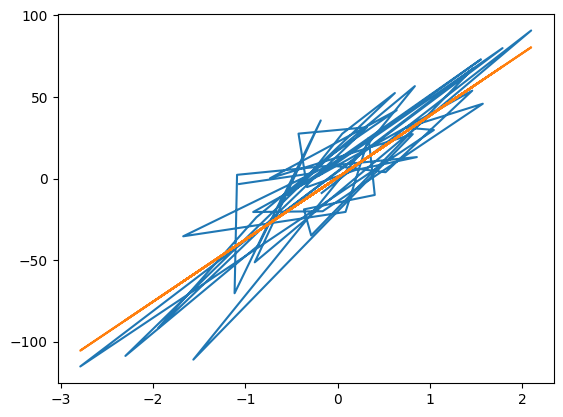

In [20]:
predicted = model(X).detach().cpu().numpy()
plt.plot(X.cpu().numpy()[:50], Y.cpu().numpy()[:50])
plt.plot(X.cpu().numpy()[:50], predicted[:50])
plt.show()